# Tai Dinh, Week 2, IDX Exchange

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Loading Data
We load in 6 months of the data.


In [3]:
jan24 = pd.read_csv('/content/drive/MyDrive/IDX_data/CRMLSSold202401_filled.csv')
feb24 = pd.read_csv('/content/drive/MyDrive/IDX_data/CRMLSSold202402_filled.csv')
mar25 = pd.read_csv('/content/drive/MyDrive/IDX_data/CRMLSSold202503.csv')
april25 = pd.read_csv('/content/drive/MyDrive/IDX_data/CRMLSSold202504.csv')
april26 = pd.read_csv('/content/drive/MyDrive/IDX_data/CRMLSSold202604.csv')
may26 = pd.read_csv('/content/drive/MyDrive/IDX_data/CRMLSSold202605.csv')

In [4]:
#check one data set
jan24.head(5)

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,NaN,False,1.0,Other,94401,6472.0,NaN,NaN,True,True
1,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,2024-01-24,950.0,...,NaN,NaN,NaN,NaN,92394,NaN,52320.0,NaN,False,False
2,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,2024-01-16,45000.0,...,NaN,False,NaN,NaN,93240,NaN,217364.0,NaN,False,False
3,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,2024-01-08,141500.0,...,NaN,False,NaN,NaN,92308,NaN,217800.0,NaN,False,False
4,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,2024-01-17,15000.0,...,NaN,False,NaN,NaN,93544,0.0,108883.0,NaN,False,False


In [5]:
dfs = [jan24, feb24, mar25, april25, april26, may26]
df = pd.concat(dfs, ignore_index=True)

In [6]:
df.shape
df.head()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,1.0,Other,94401,6472.0,NaN,NaN,True,True,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,2024-01-24,950.0,...,NaN,NaN,92394,NaN,52320.0,NaN,False,False,NaN,NaN
2,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,2024-01-16,45000.0,...,NaN,NaN,93240,NaN,217364.0,NaN,False,False,NaN,NaN
3,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,2024-01-08,141500.0,...,NaN,NaN,92308,NaN,217800.0,NaN,False,False,NaN,NaN
4,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,2024-01-17,15000.0,...,NaN,NaN,93544,0.0,108883.0,NaN,False,False,NaN,NaN


In [7]:
#focus on residential single family homes
df = df[(df["PropertyType"] == "Residential") & (df["PropertySubType"] == "SingleFamilyResidence")]

In [15]:
#shape and info on filtered dataset
print(df.shape)
df.info()

(64431, 82)
<class 'pandas.core.frame.DataFrame'>
Index: 64431 entries, 5 to 129258
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Flooring                      40920 non-null  object 
 1   ViewYN                        58727 non-null  object 
 2   WaterfrontYN                  37 non-null     object 
 3   BasementYN                    1536 non-null   object 
 4   PoolPrivateYN                 59017 non-null  object 
 5   OriginalListPrice             64287 non-null  float64
 6   ListingKey                    64431 non-null  int64  
 7   ListAgentEmail                64291 non-null  object 
 8   CloseDate                     64431 non-null  object 
 9   ClosePrice                    64431 non-null  float64
 10  ListAgentFirstName            63993 non-null  object 
 11  ListAgentLastName             64423 non-null  object 
 12  Latitude                      64406 non-null  float6

In [9]:
#investigate distributions of ClosePrice, LivingArea, Bedrooms, Bathrooms, LotSize and rename columns
cols = ["ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeArea"]
df_filt = df[cols]
df_filt = df_filt.rename(columns = {'BedroomsTotal':'Bedrooms', 'BathroomsTotalInteger':'Bathrooms', 'LotSizeArea':'LotSize'})

In [10]:
df_filt.head(5)

,ClosePrice,LivingArea,Bedrooms,Bathrooms,LotSize
5,815000.0,1974.0,4.0,4.0,NaN
9,810000.0,1974.0,4.0,4.0,NaN
28,2100000.0,3736.0,4.0,4.0,11219.00
29,1950000.0,2100.0,3.0,0.0,1.71
31,2340000.0,2442.0,4.0,3.0,8712.00


<Axes: >

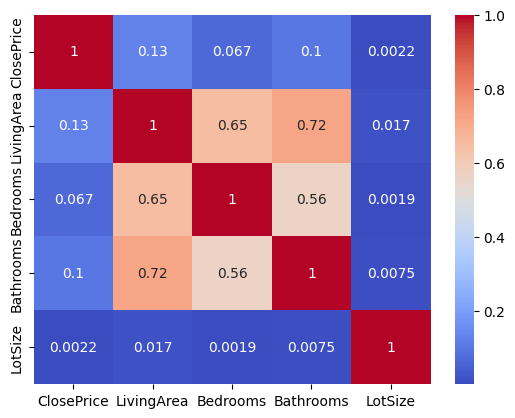

In [11]:
# look at correlations between different variables
sns.heatmap(df_filt.corr(), annot=True, cmap='coolwarm')

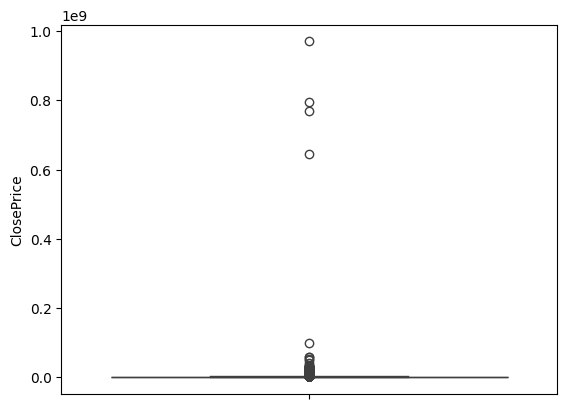

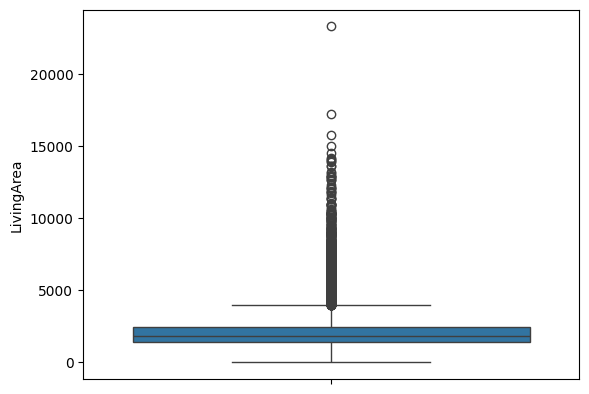

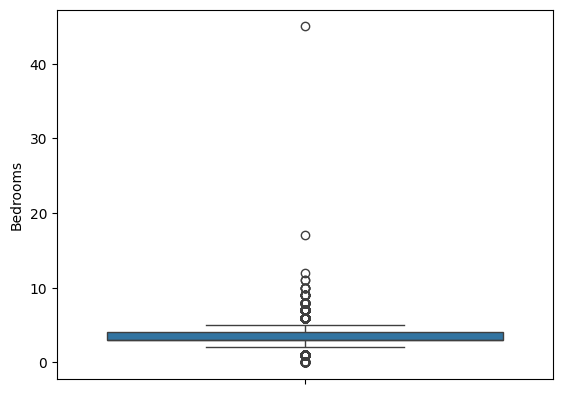

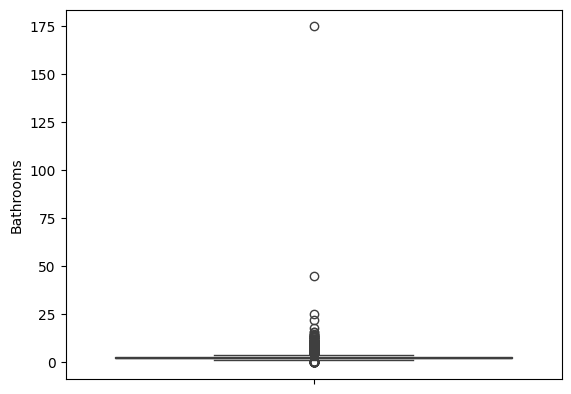

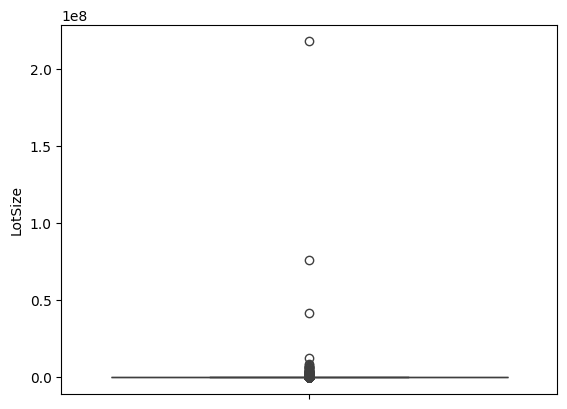

In [12]:
#make boxplots of data, looking at how spread out the columns are and their outliers
cols = ["ClosePrice", "LivingArea", "Bedrooms", "Bathrooms", "LotSize"]
for x in cols:
  sns.boxplot(df_filt[x])
  plt.show()

In [13]:
#get the mean, quartiles and other important statistics about each column
df_filt.describe()

,ClosePrice,LivingArea,Bedrooms,Bathrooms,LotSize
count,6.443100e+04,64397.000000,64431.000000,64424.000000,6.326700e+04
mean,1.302748e+06,2036.838115,3.476168,2.628167,2.295147e+04
std,6.488464e+06,1017.571542,0.965051,1.323694,9.402040e+05
min,6.850000e+02,0.000000,0.000000,0.000000,0.000000e+00
25%,6.150000e+05,1378.000000,3.000000,2.000000,5.446000e+03
50%,8.850000e+05,1810.000000,3.000000,2.000000,7.100000e+03
75%,1.425000e+06,2430.000000,4.000000,3.000000,9.927000e+03
max,9.700000e+08,23314.000000,45.000000,175.000000,2.178000e+08


Our data seems to have a handful of extremely high outliers. These are most likely the extremely expensive and luxurious properties.

<Axes: xlabel='ClosePrice', ylabel='Density'>

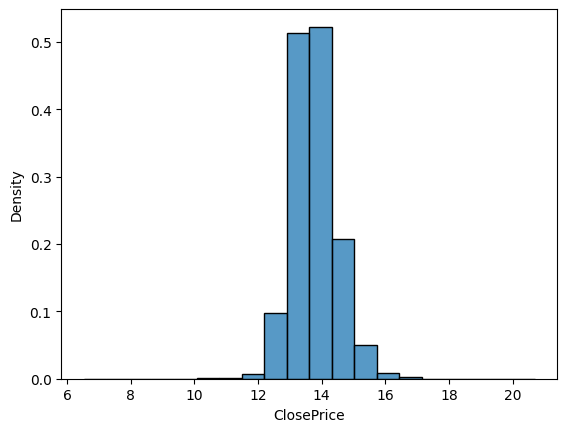

In [19]:
# use log to "Squish" down outliers
sns.histplot(np.log(df_filt["ClosePrice"]), stat = "density", bins = 20)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='LivingArea', ylabel='Density'>

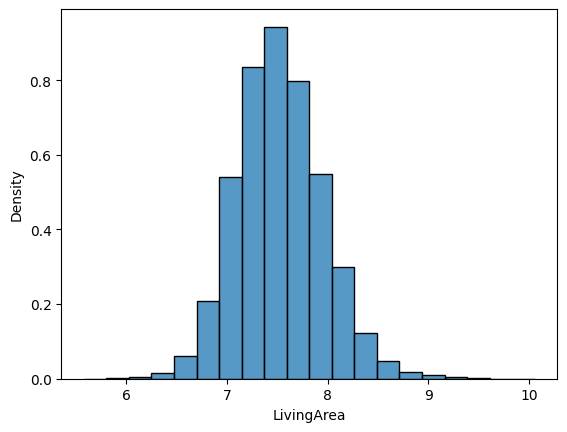

In [21]:
sns.histplot(np.log(df_filt["LivingArea"]), stat = "density", bins = 20)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Bedrooms', ylabel='Density'>

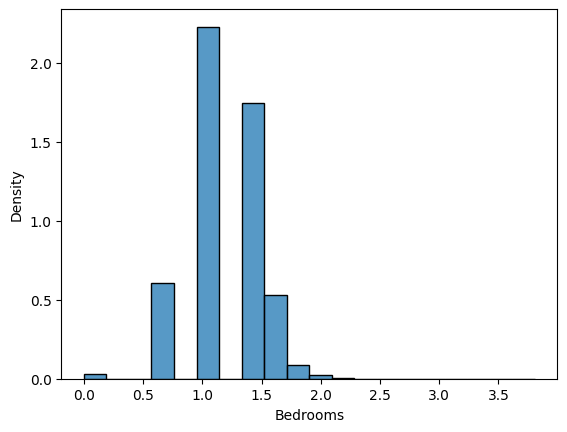

In [22]:
#Bedrooms seem to be more segmented, not as continuous data
sns.histplot(np.log(df_filt["Bedrooms"]), stat = "density", bins = 20)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Bathrooms', ylabel='Density'>

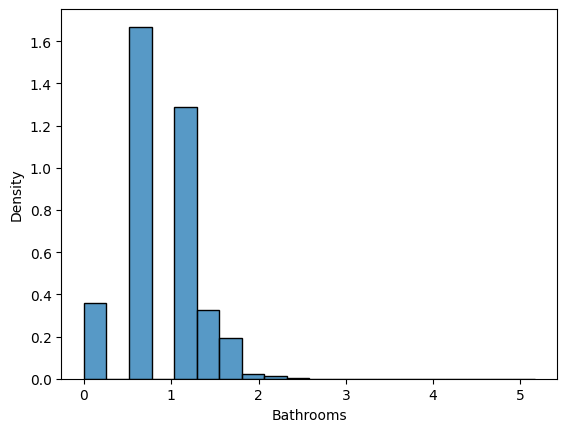

In [23]:
#interestingly, log(bathrooms) histogram seems to be a translation of log(bedrooms) data, the two are highly correlated
sns.histplot(np.log(df_filt["Bathrooms"]), stat = "density", bins = 20)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='LotSize', ylabel='Density'>

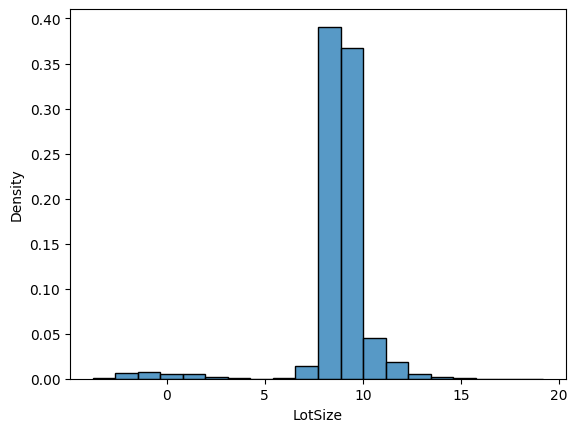

In [24]:
sns.histplot(np.log(df_filt["LotSize"]), stat = "density", bins = 20)

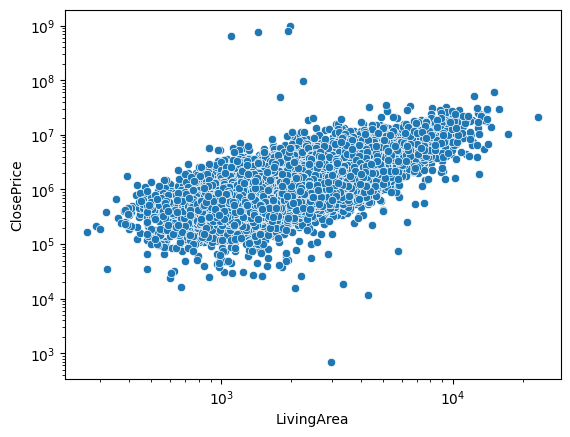

In [27]:
#making scatterplots of closeprice vs. other variables
sns.scatterplot(data = df_filt, x = "LivingArea", y = "ClosePrice")
plt.xscale("log")
plt.yscale("log")
plt.show()

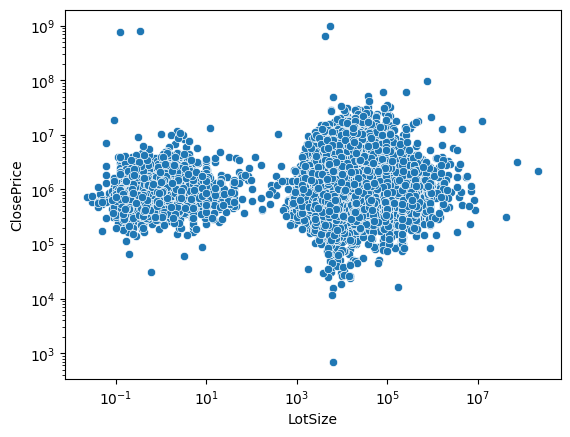

In [30]:
#2 clumps of data, not sure what this means?
sns.scatterplot(data = df_filt, x = "LotSize", y = "ClosePrice")
plt.xscale("log")
plt.yscale("log")
plt.show()